In [7]:
import numpy as np
import pandas as pd

In [8]:
suspects = np.array(['Ez', 'Vicky', 'Professor', 'Thalia'])
weapons = np.array(['Book', 'Beaker', 'Stapler'])

prior_probs = np.array([0.20, 0.20, 0.40, 0.20])   # P(Ez), P(Vicky), P(Professor), P(Thalia)

ez_probs = np.array([0.15, 0.20, 0.65])        # Book, Beaker, Stapler
vicky_probs = np.array([0.75, 0.10, 0.15])
professor_probs = np.array([0.05, 0.70, 0.25])
thalia_probs = np.array([0.15, 0.60, 0.25])

In [9]:
def draw_prior(suspects, probs, N):
    return np.random.choice(suspects, size=N, p=probs)

def draw_model(weapons, suspect_draws):
    
    weapon_draws = np.empty(len(suspect_draws), dtype=object)
    
    ez_mask = suspect_draws == 'Ez'
    vicky_mask = suspect_draws == 'Vicky'
    professor_mask = suspect_draws == 'Professor'
    thalia_mask = suspect_draws == 'Thalia'
    
    weapon_draws[ez_mask] = np.random.choice(
        weapons, size=ez_mask.sum(), p=ez_probs
    )
    
    weapon_draws[vicky_mask] = np.random.choice(
        weapons, size=vicky_mask.sum(), p=vicky_probs
    )
    
    weapon_draws[professor_mask] = np.random.choice(
        weapons, size=professor_mask.sum(), p=professor_probs
    )
    
    weapon_draws[thalia_mask] = np.random.choice(
        weapons, size=thalia_mask.sum(), p=thalia_probs
    )
    
    return weapon_draws


def draw_joint(weapons, suspects, prior_probs, N):
    
    suspect_draws = draw_prior(suspects, prior_probs, N)
    weapon_draws = draw_model(weapons, suspect_draws)
    
    return suspect_draws, weapon_draws

def simulator(weapons, suspects, prior_probs, N=10000):
    return draw_joint(weapons, suspects, prior_probs, N)


In [10]:
num_sims = 100_000

suspect_draws, weapon_draws = simulator(
    weapons, suspects, prior_probs, N=num_sims
)

joint_strings = np.char.add(suspect_draws, "_" + weapon_draws)

scenarios, counts = np.unique(joint_strings, return_counts=True)


In [11]:
probs = counts / num_sims

df_results = pd.DataFrame({
    "Suspect": [s.split("_")[0] for s in scenarios],
    "Weapon": [s.split("_")[1] for s in scenarios],
    "Count": counts,
    "Estimated Probability": probs
})

df_results


,Suspect,Weapon,Count,Estimated Probability
0,Ez,Beaker,3993,0.03993
1,Ez,Book,2965,0.02965
2,Ez,Stapler,13071,0.13071
3,Professor,Beaker,27870,0.27870
4,Professor,Book,1970,0.01970
5,Professor,Stapler,10229,0.10229
6,Thalia,Beaker,11894,0.11894
7,Thalia,Book,2936,0.02936
8,Thalia,Stapler,4912,0.04912
9,Vicky,Beaker,2072,0.02072


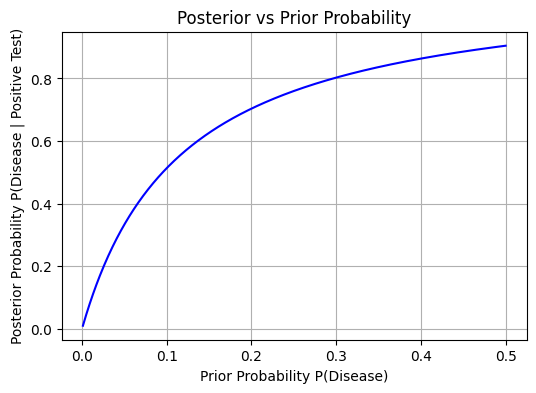

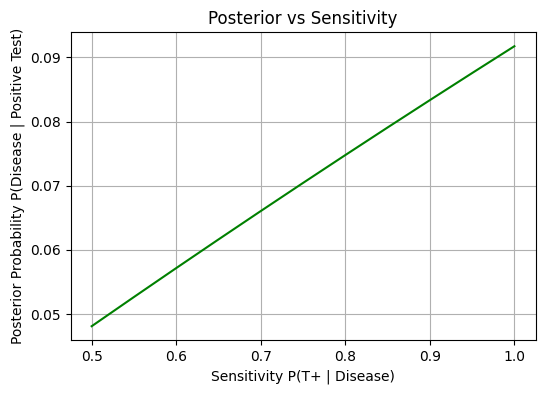

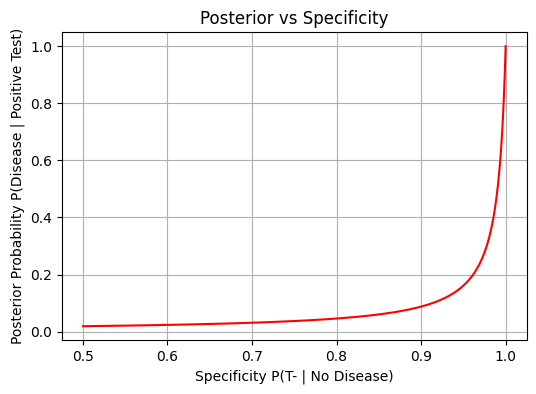

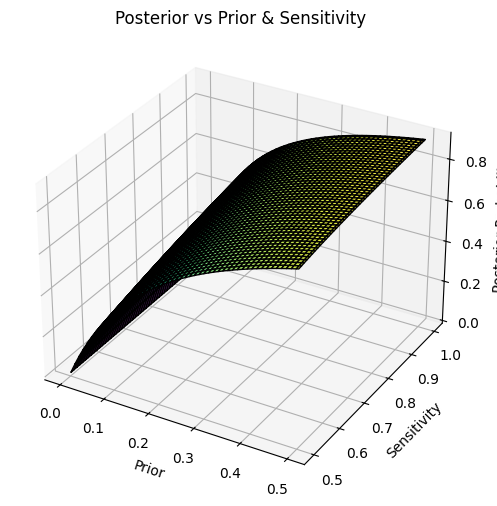

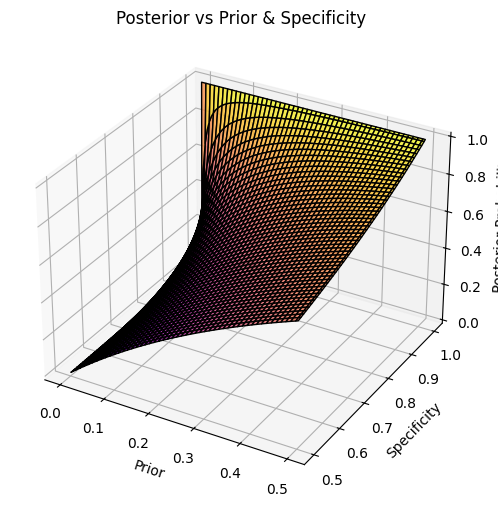

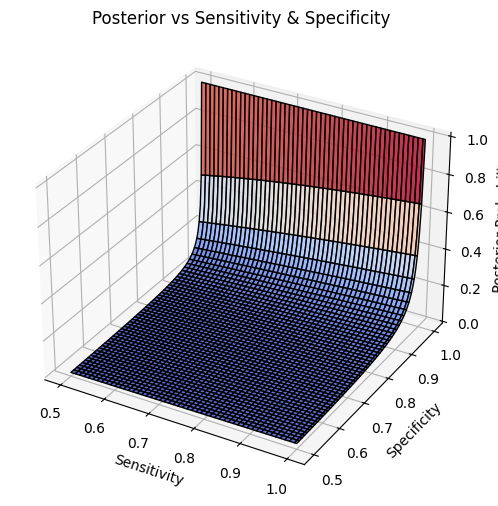

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# Base values
prior_base = 0.01
sensitivity_base = 0.95
specificity_base = 0.90

# Vectorized function for posterior probability
def posterior(prior, sensitivity, specificity):
    prior = np.array(prior)
    return (sensitivity * prior) / (sensitivity * prior + (1 - specificity) * (1 - prior))

# ------------------------------
# 2D plots (as before)
# ------------------------------

# 1. Posterior vs Prior
priors = np.linspace(0.001, 0.5, 500)
posterior_vs_prior = posterior(priors, sensitivity_base, specificity_base)

plt.figure(figsize=(6,4))
plt.plot(priors, posterior_vs_prior, color='blue')
plt.xlabel("Prior Probability P(Disease)")
plt.ylabel("Posterior Probability P(Disease | Positive Test)")
plt.title("Posterior vs Prior Probability")
plt.grid(True)
plt.show()

# 2. Posterior vs Sensitivity
sensitivities = np.linspace(0.5, 1.0, 500)
posterior_vs_sens = posterior(prior_base, sensitivities, specificity_base)

plt.figure(figsize=(6,4))
plt.plot(sensitivities, posterior_vs_sens, color='green')
plt.xlabel("Sensitivity P(T+ | Disease)")
plt.ylabel("Posterior Probability P(Disease | Positive Test)")
plt.title("Posterior vs Sensitivity")
plt.grid(True)
plt.show()

# 3. Posterior vs Specificity
specificities = np.linspace(0.5, 1.0, 500)
posterior_vs_spec = posterior(prior_base, sensitivity_base, specificities)

plt.figure(figsize=(6,4))
plt.plot(specificities, posterior_vs_spec, color='red')
plt.xlabel("Specificity P(T- | No Disease)")
plt.ylabel("Posterior Probability P(Disease | Positive Test)")
plt.title("Posterior vs Specificity")
plt.grid(True)
plt.show()

# ------------------------------
# Bonus: 3D surface plots
# ------------------------------

# 1. Prior vs Sensitivity
prior_vals = np.linspace(0.001, 0.5, 100)
sensitivity_vals = np.linspace(0.5, 1.0, 100)
P, S = np.meshgrid(prior_vals, sensitivity_vals)
Z1 = posterior(P, S, specificity_base)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(P, S, Z1, cmap='viridis', edgecolor='k', alpha=0.8)
ax.set_xlabel("Prior")
ax.set_ylabel("Sensitivity")
ax.set_zlabel("Posterior Probability")
ax.set_title("Posterior vs Prior & Sensitivity")
plt.show()

# 2. Prior vs Specificity
specificity_vals = np.linspace(0.5, 1.0, 100)
P, Sp = np.meshgrid(prior_vals, specificity_vals)
Z2 = posterior(P, sensitivity_base, Sp)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(P, Sp, Z2, cmap='plasma', edgecolor='k', alpha=0.8)
ax.set_xlabel("Prior")
ax.set_ylabel("Specificity")
ax.set_zlabel("Posterior Probability")
ax.set_title("Posterior vs Prior & Specificity")
plt.show()

# 3. Sensitivity vs Specificity
S, Sp = np.meshgrid(sensitivity_vals, specificity_vals)
Z3 = posterior(prior_base, S, Sp)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, Sp, Z3, cmap='coolwarm', edgecolor='k', alpha=0.8)
ax.set_xlabel("Sensitivity")
ax.set_ylabel("Specificity")
ax.set_zlabel("Posterior Probability")
ax.set_title("Posterior vs Sensitivity & Specificity")
plt.show()
